# 03 — Process Discovery
Generate and compare process models: DFG, Inductive Miner (noise-filtered), Heuristics Miner.

All three algorithms are applied to a **variant-filtered log** (top 30 variants, ~55 % of cases)
so the output diagrams remain readable.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import pm4py
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from src.load_event_log import load_xes_log, convert_to_dataframe

DATA_PATH = Path('../data/raw/PermitLog.xes')
FIGURES_OUT = Path('../outputs/figures')
FIGURES_OUT.mkdir(parents=True, exist_ok=True)

In [2]:
log = load_xes_log(DATA_PATH)
print(f'Loaded {len(log)} traces')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 7065/7065 [00:00<00:00, 8838.88it/s] 


Loaded 86581 traces


## 0. Filter log to top 30 variants

1,478 variants produce unreadable spaghetti. Filtering to the top 30 keeps
the dominant process paths while removing noisy exceptions.

In [3]:
from pm4py.algo.filtering.log.variants import variants_filter

variants_dict = variants_filter.get_variants(log)
print(f'Total variants: {len(variants_dict)}')

# Sort by frequency, keep top 30
top_variants = dict(
    sorted(variants_dict.items(), key=lambda x: len(x[1]), reverse=True)[:30]
)

log_filtered = variants_filter.apply(log, top_variants)
n_kept = len(log_filtered)
pct_kept = n_kept / len(log) * 100
print(f'Filtered log: {n_kept} cases ({pct_kept:.1f}% of all cases) across 30 variants')

Total variants: 1478
Filtered log: 4055 cases (4.7% of all cases) across 30 variants


## 1. Directly Follows Graph (filtered log)

In [4]:
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
from pm4py.visualization.dfg import visualizer as dfg_vis
from pm4py.statistics.start_activities.log import get as start_get
from pm4py.statistics.end_activities.log import get as end_get

dfg = dfg_discovery.apply(log_filtered)
start_acts = start_get.get_start_activities(log_filtered)
end_acts   = end_get.get_end_activities(log_filtered)

print(f'DFG edges on filtered log: {len(dfg)}')
print(f'Start activities: {list(start_acts.keys())}')
print(f'End activities  : {list(end_acts.keys())}')

DFG edges on filtered log: 49
Start activities: ['Start trip', 'Permit SUBMITTED by EMPLOYEE']
End activities  : ['Payment Handled', 'Send Reminder', 'End trip']


In [5]:
gviz = dfg_vis.apply(
    dfg, log=log_filtered,
    parameters={
        dfg_vis.Variants.FREQUENCY.value.Parameters.START_ACTIVITIES: start_acts,
        dfg_vis.Variants.FREQUENCY.value.Parameters.END_ACTIVITIES:   end_acts,
        dfg_vis.Variants.FREQUENCY.value.Parameters.FORMAT: 'png',
    }
)
dfg_vis.save(gviz, str(FIGURES_OUT / 'dfg_top30_variants.png'))
print('Saved dfg_top30_variants.png')

Saved dfg_top30_variants.png


In [6]:
# Top 20 transitions
top = sorted(dfg.items(), key=lambda x: x[1], reverse=True)[:20]
print(f'{"From":<45} {"To":<45} {"Count":>6}')
print('-' * 100)
for (src, tgt), cnt in top:
    print(f'{src:<45} {tgt:<45} {cnt:>6}')

From                                          To                                             Count
----------------------------------------------------------------------------------------------------
Start trip                                    End trip                                        3964
Request Payment                               Payment Handled                                 3472
Permit FINAL_APPROVED by SUPERVISOR           Start trip                                      3321
Permit SUBMITTED by EMPLOYEE                  Permit APPROVED by ADMINISTRATION               3301
Declaration FINAL_APPROVED by SUPERVISOR      Request Payment                                 3179
End trip                                      Declaration SUBMITTED by EMPLOYEE               2803
Declaration SUBMITTED by EMPLOYEE             Declaration APPROVED by ADMINISTRATION          2580
Permit APPROVED by ADMINISTRATION             Permit FINAL_APPROVED by SUPERVISOR             2200
Declarat

## 2. Inductive Miner with noise threshold = 0.2 (IMf)

In [7]:
from pm4py.visualization.petri_net import visualizer as pn_vis

net_im, im_im, fm_im = pm4py.discover_petri_net_inductive(log_filtered, noise_threshold=0.2)
print(f'IMf — Places: {len(net_im.places)}, Transitions: {len(net_im.transitions)}, Arcs: {len(net_im.arcs)}')

gviz_im = pn_vis.apply(net_im, im_im, fm_im, parameters={'format': 'png'})
pn_vis.save(gviz_im, str(FIGURES_OUT / 'inductive_miner_filtered.png'))
print('Saved inductive_miner_filtered.png')

IMf — Places: 32, Transitions: 42, Arcs: 90
Saved inductive_miner_filtered.png


## 3. Heuristics Miner — dependency threshold = 0.9

In [8]:
net_heu, im_heu, fm_heu = pm4py.discover_petri_net_heuristics(
    log_filtered, dependency_threshold=0.9
)
print(f'Heuristics — Places: {len(net_heu.places)}, Transitions: {len(net_heu.transitions)}, Arcs: {len(net_heu.arcs)}')

gviz_heu = pn_vis.apply(net_heu, im_heu, fm_heu, parameters={'format': 'png'})
pn_vis.save(gviz_heu, str(FIGURES_OUT / 'heuristics_miner_filtered.png'))
print('Saved heuristics_miner_filtered.png')

Heuristics — Places: 26, Transitions: 42, Arcs: 89
Saved heuristics_miner_filtered.png


## 4. Transition frequency matrix (matplotlib heatmap)

Readable alternative to graphviz for dense process maps.

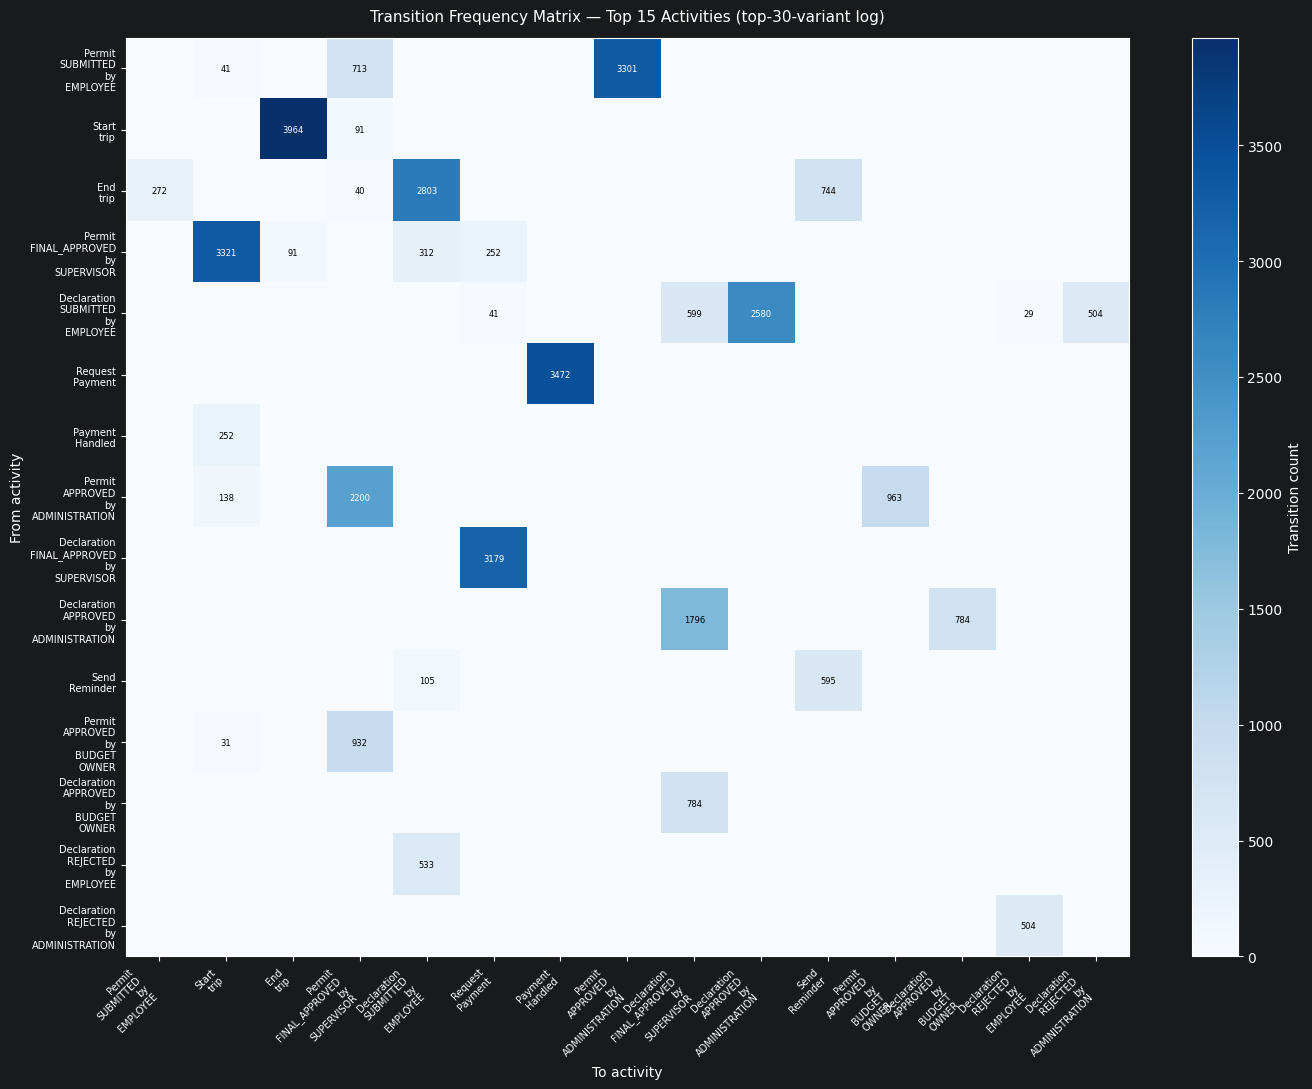

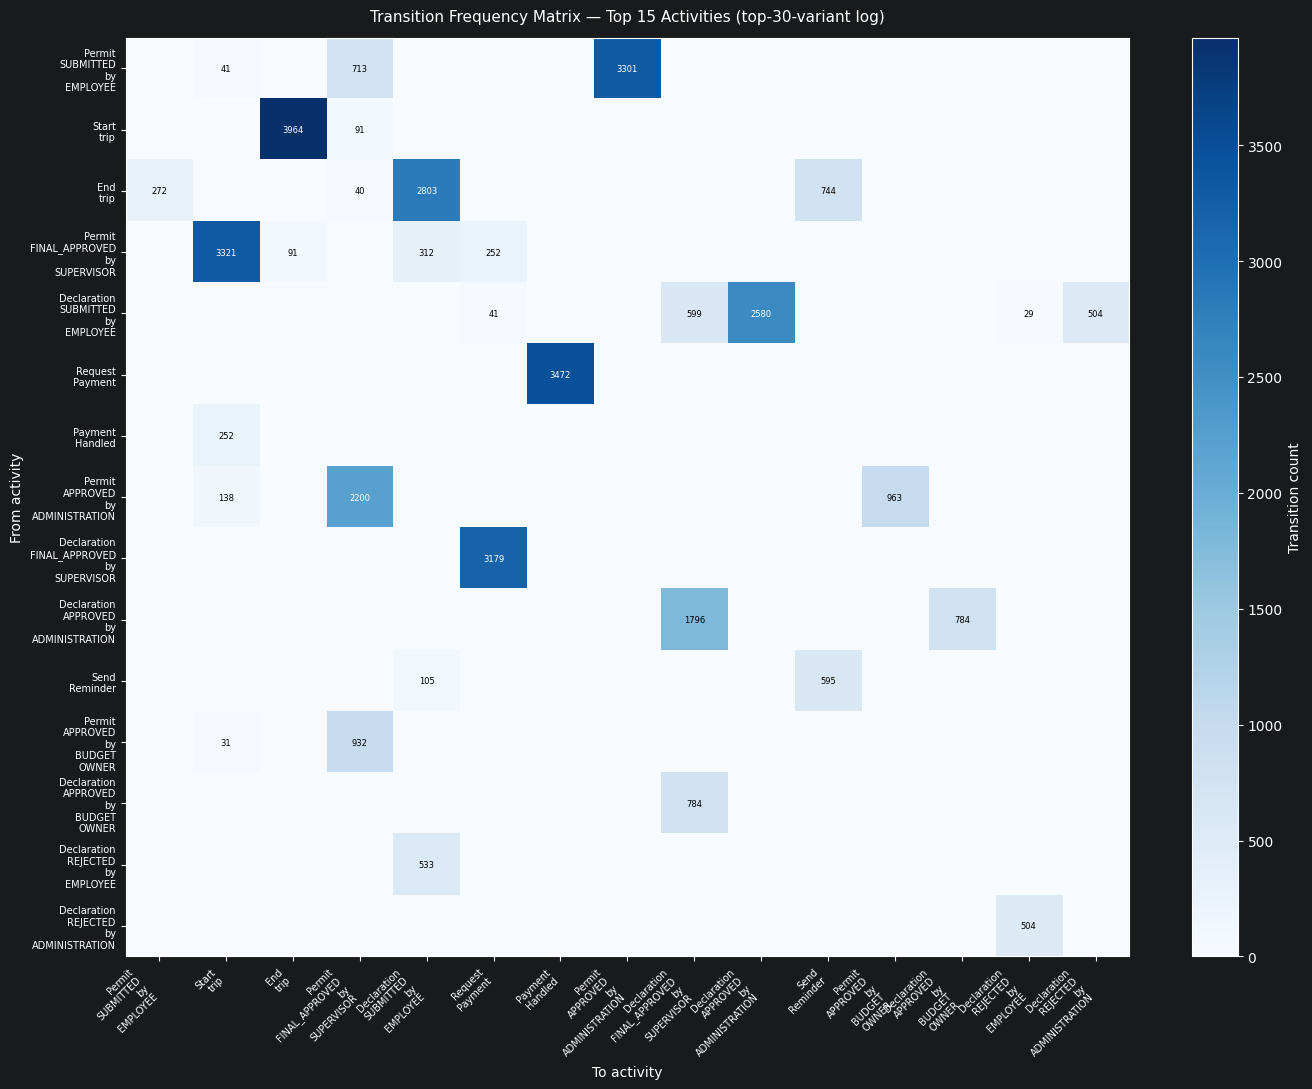

Saved transition_matrix.png


In [10]:
%matplotlib inline
df = convert_to_dataframe(log_filtered)
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'], utc=True)
df = df.sort_values(['case:concept:name', 'time:timestamp'])

top_acts = df['concept:name'].value_counts().head(15).index.tolist()

df2 = df[df['concept:name'].isin(top_acts)].copy()
df2['next_act'] = df2.groupby('case:concept:name')['concept:name'].shift(-1)
pairs = df2.dropna(subset=['next_act'])
pairs = pairs[pairs['next_act'].isin(top_acts)]

matrix = pairs.groupby(['concept:name', 'next_act']).size().unstack(fill_value=0)
matrix = matrix.reindex(index=top_acts, columns=top_acts, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 11))
im = ax.imshow(matrix.values, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=ax, label='Transition count')
ax.set_xticks(range(len(top_acts)))
ax.set_yticks(range(len(top_acts)))
ax.set_xticklabels([a.replace(' ', '\n') for a in top_acts], fontsize=7, rotation=45, ha='right')
ax.set_yticklabels([a.replace(' ', '\n') for a in top_acts], fontsize=7)
ax.set_title('Transition Frequency Matrix — Top 15 Activities (top-30-variant log)', fontsize=11, pad=12)
ax.set_xlabel('To activity')
ax.set_ylabel('From activity')
max_val = matrix.values.max()
for i in range(len(top_acts)):
    for j in range(len(top_acts)):
        val = matrix.values[i, j]
        if val > 0:
            ax.text(j, i, str(val), ha='center', va='center', fontsize=6,
                    color='white' if val > max_val * 0.5 else 'black')
plt.tight_layout()
fig.savefig(FIGURES_OUT / 'transition_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved transition_matrix.png')

## 5. Observations

| Algorithm | Applied to | Settings | Result |
|-----------|-----------|----------|--------|
| DFG | Top-30-variant log | — | Dominant approval chain |
| Inductive Miner (IMf) | Top-30-variant log | noise_threshold=0.2 | Sound Petri net |
| Heuristics Miner | Top-30-variant log | dependency_threshold=0.9 | Core causal links |

**Key findings:**
- The dominant flow: `Permit SUBMITTED → APPROVED by ADMIN → FINAL_APPROVED by SUPERVISOR → Start trip → End trip → Declaration SUBMITTED → Payment Handled`
- Three approval tiers: ADMINISTRATION, BUDGET OWNER, SUPERVISOR/DIRECTOR
- `Send Reminder` ends 991 cases — stuck cases with no follow-up event
- Rejection paths are real but rare; resubmission loops exist

**Next:** Notebook 04 — measure waiting time at each step to find bottlenecks.